In [1]:
%load_ext autoreload
%autoreload 2

# Importing the modules

import config_dict as cfg                    # config = physical & simulation parameters 
from solver_2DHcurl_1DH1 import *            # solver = mesh build, physics import and FEM method + pmls initialization
# from solver_2DHcurl_1DH1_Copie import *
import PP_Run_and_Save as pp_run     # post process run and save = run scan function and save data in H5 files
import PP_Plot_and_Load as pp_plot   # post process load and plot = recover the sim data from H5 files and plot graphs "instantly"

import Antenna_Desc_n_Plot as antenna

geom_mode = "1D" # "1D" or "2D" 
box_medium = "PLASMA" # "VACUUM" or "PLASMA" 

antenna_grill = None
if antenna_grill != None:
    antenna_grill = antenna.AntennaGrill(b_active=0.009, d_septa=0.002, d_gap=0.010)
    antenna_grill.add_module(num_active=10, delta_phi_deg=90, is_PAM=False)

    instructions = antenna_grill.generate_mesh_instructions()
    antenna.plot_antenna_blueprint(instructions)

solver = LHCouplingSolver_2DHcurl_1DH1(cfg.__dict__, geom_mode, box_medium, antenna_grill)

n_e = 5.00e+18 m^-3
n_acc(ne=5.00e+18 m^-3) = 1.21
In LHCoupling class: n_para: 2.0+0.0j, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j


In [9]:
mesh = solver.build_mesh_with_PMLs()
solver.build_physics_Stix_B_field()

GF_E_field, Gamma_R, Gamma_T, diag_data = solver.solve_helmholtz_2DHcurl_1DH1_with_pml(mesh, geom_mode, box_medium)

geom_mode: 1D
box_medium: PLASMA
[!] MEDIUM = PLASMA, Lx_pml is set based on lambda_perp_p
==== 
Lx_plasma: 5.00e-02m,   Lx_pml: 2.71e-02m,    Lx_tot: 7.71e-02m
Lx_wg = 0.00e+00m
Lz_antenna: 0.00e+00m, Lz_wall: 0.00e+00m
Lz_plasma: 1.22e-01m, Lz_pml: 0.00e+00m, Lz_tot: 1.22e-01m
==== 
n_∥: 2.0+0.0j,   λ_∥: 4.05e-02m 
n_⟂⁺:8.98+0.00j, λ_⟂⁺: 9.02e-03m 
n_⟂-:0.00+1.63j, λ_⟂⁻: 4.98e-02m
==== 
n_index_meshing: 8.98 
λ_meshing: 9.02e-03m 
maxh_plasma: 1.13e-03m
[DOMAIN 1D DEFINED]
[MESH GENERATED !]
==== 
#DoFs = 364266
--- Solving the 3D vector linear system ---
==== 
w_size_R: 1.3531e-02m,    w_size_T: 6.0769e-02m
Gamma_R (SWR) = 3.444e-03
Gamma_T (SWR) = 6.434e-03

--- Poynting Flux & Energy Conservation ---
Net Power Injected (Antenna): 5.6949e-02 W/m
Net Power Exiting to PMLs:    5.6911e-02 W/m
Plasma Bulk Conservation Error: 6.65e-02 %


In [10]:
# Create the Run_XXX_XXX file in Simulation_Results folder
# run_folder = /Simulation_Results/Run_XXX
run_folder_path = pp_run.setup_output_directory("Simulation_Results", save_data=True)

# Total Run_XXX folder path to Remi's shared zone (cea intra) 
# run_folder_tot_path = "/home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/" + run_folder_path
run_folder_tot_path = '/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/' + run_folder_path
print(f'sim_target_folder: {run_folder_tot_path}')



[SYSTEM] Output directory created: Simulation_Results/Run_20260702_094452
sim_target_folder: /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260702_094452


--- Extracting 2D Wave Map ---
Lz_plasma_src: 0.122, Lz_wall: 0.000, Lz_pml: 0.000, Lz_tot: 0.122
Bornes géométriques fixées
  --> Pure Multithreaded C++ vectorized interpolation...
n_e = 5.00e+18 m^-3
n_acc(ne=5.00e+18 m^-3) = 1.21
In LHCoupling class: n_para: 2.0+0.0j, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
n_e = 5.00e+18 m^-3
n_acc(ne=5.00e+18 m^-3) = 1.21
PP_run_n_save: n_para: 2.0+0.0j, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
Params recovered
h5_path = /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260702_094452/Wave_Map_2D.h5
type(h5_path) = <class 'str'>
oui

PRINT H5 METADATA:
 Lx_plasma: 5.00e-02
 Lx_pml: 2.71e-02
 Lx_tot: 7.71e-02
 Lz_plasma: 1.22e-01
 Lz_pml: 0.00e+00
 Lz_tot: 1.22e-01
 P_in_net: 5.69e-02
 P_out_Radial: 5.69e-02
 P_out_Toroidal: 0.00e+00
 eta_pred_R: 3.49e-06
 eta_pred_T: 1.00e+00
 eta_sim_R: 3.44e-03
 eta_sim_T: 6.43e-03
 k_para: (-155.09253162442445+0j)
 k_perp_p: (-696.5228085516777

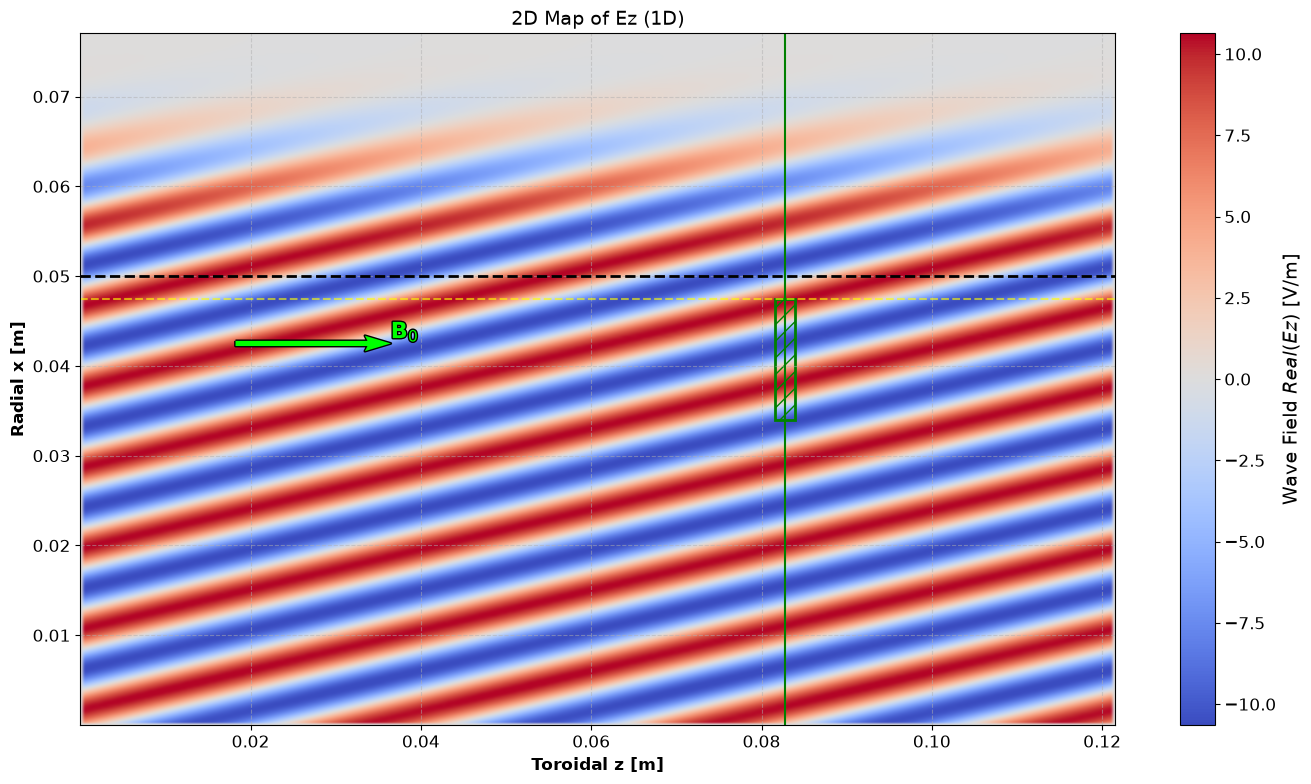

In [11]:
E_map2D_h5_filepath = pp_run.run_2D_wave_map(mesh, GF_E_field, cfg, run_folder_tot_path, geom_mode, box_medium, antenna_grill, diag_data)
# --- Post-treatment: --- 
# Generate the H5 file for 2D map plot and save it in Run_XXX folder 
# Plot E field 2D map and save it in the same folder: Run_XXX 
Lx_wg = cfg.DOMAIN.get('Lx_wg', 0.03)
Lz_wall = cfg.DOMAIN.get('Lz_wall', 0.02)

pp_plot.plot_2D_wave_map(E_map2D_h5_filepath, run_folder_tot_path, geom_mode, component='Ez', value_type='real',
                         antenna_grill=antenna_grill, Lx_wg=Lx_wg, Lz_wall=Lz_wall, plot_poynting=False, show_windows=True, Poynting_box=False)

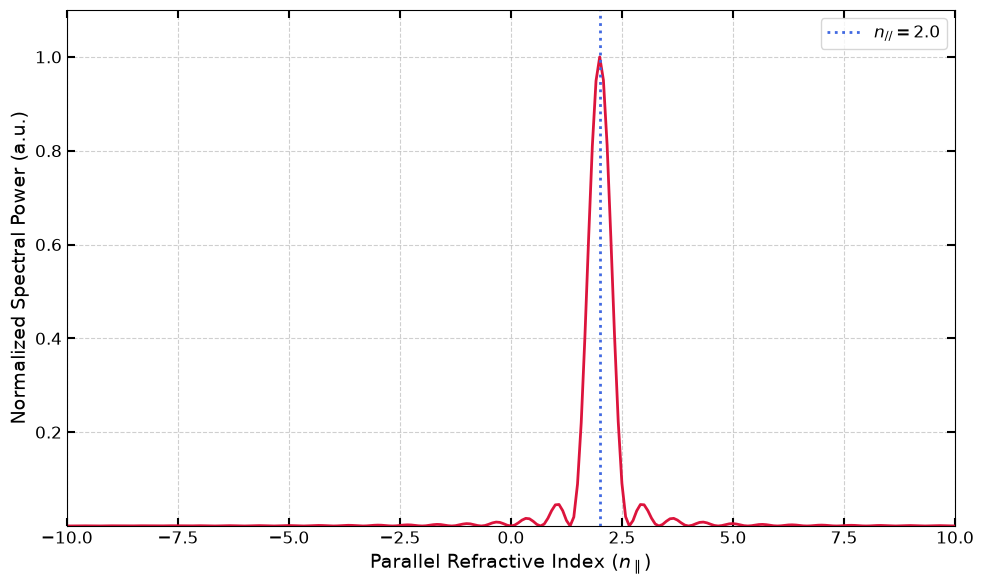

In [13]:
# Test n_para spectrum

n_para_array, power_spectrum = pp_plot.plot_n_para_spectrum(mesh, GF_E_field, cfg, geom_mode, x_eval=0.07)


In [6]:
import sweep_param_functions as spf

# db_filepath = spf.generate_1D_radial_pml_database(cfg.__dict__, geom_mode, box_medium,save_dir="Simulation_Results")

--- Création des graphiques multi-spectres depuis : Simulation_Results/1D_PLASMA_n_para=2_ppw_6_to_20_40pts.h5 ---
param_values: []
 ==== key: Lx_pml_ratio ====
dofs: []
Gamma_R: []
Lx_pml: []
parameter_is_ppw: None
  -> Graphe sauvegardé : Analyse_Spectrale_Sweep_Lpml_Ratio.svg


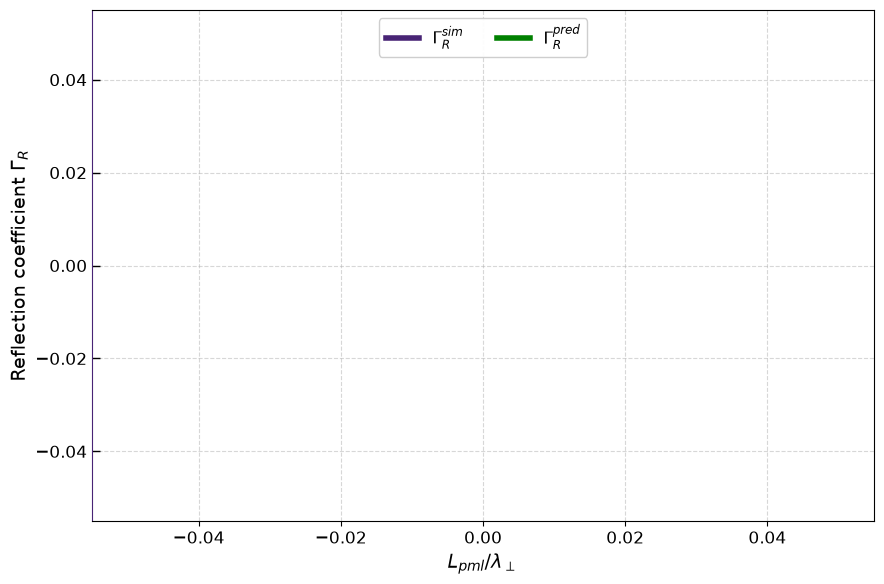

param_values: [ 6.          6.35897436  6.71794872  7.07692308  7.43589744  7.79487179
  8.15384615  8.51282051  8.87179487  9.23076923  9.58974359  9.94871795
 10.30769231 10.66666667 11.02564103 11.38461538 11.74358974 12.1025641
 12.46153846 12.82051282 13.17948718 13.53846154 13.8974359  14.25641026
 14.61538462 14.97435897 15.33333333 15.69230769 16.05128205 16.41025641
 16.76923077 17.12820513 17.48717949 17.84615385 18.20512821 18.56410256
 18.92307692 19.28205128 19.64102564 20.        ]
 ==== key: ppw_pml ====
dofs: [326246 331099 335397 338659 342550 346626 343948 347114 351138 351582
 354918 356863 359333 346630 347746 347974 349830 350872 352706 359964
 366112 363565 364984 364176 376474 369938 374125 377609 380161 380656
 379200 382107 372700 381468 387425 386574 380986 371223 373434 368860]
Gamma_R: [0.00207751 0.00314526 0.00379679 0.00351353 0.00337721 0.00339456
 0.00337792 0.00447022 0.00414381 0.00430645 0.00332939 0.0032645
 0.00325223 0.00333462 0.00357078 0.004011

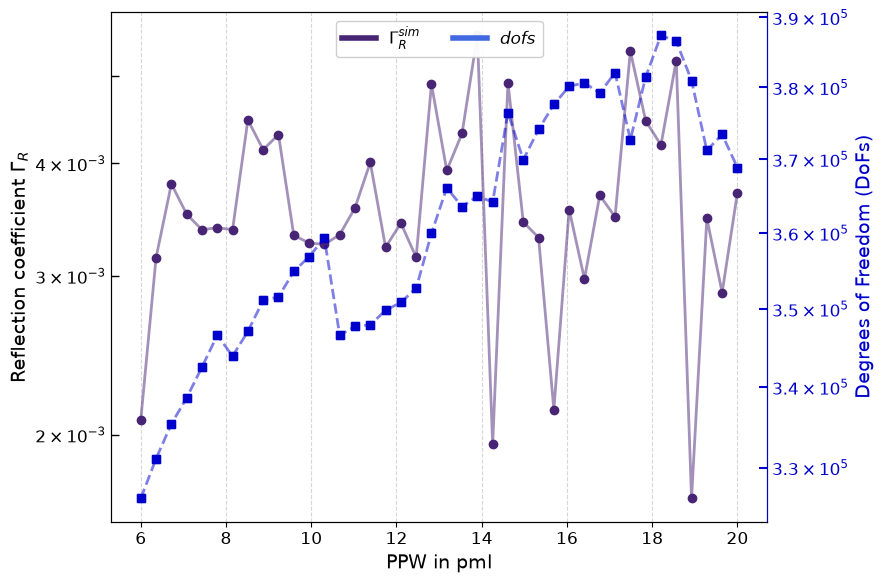

param_values: []
 ==== key: ppw_medium ====
dofs: []
Gamma_R: []
Lx_pml: []
parameter_is_ppw: ppw_medium
  -> Graphe sauvegardé : Analyse_Spectrale_Sweep_Resolution_PPW_Medium.svg


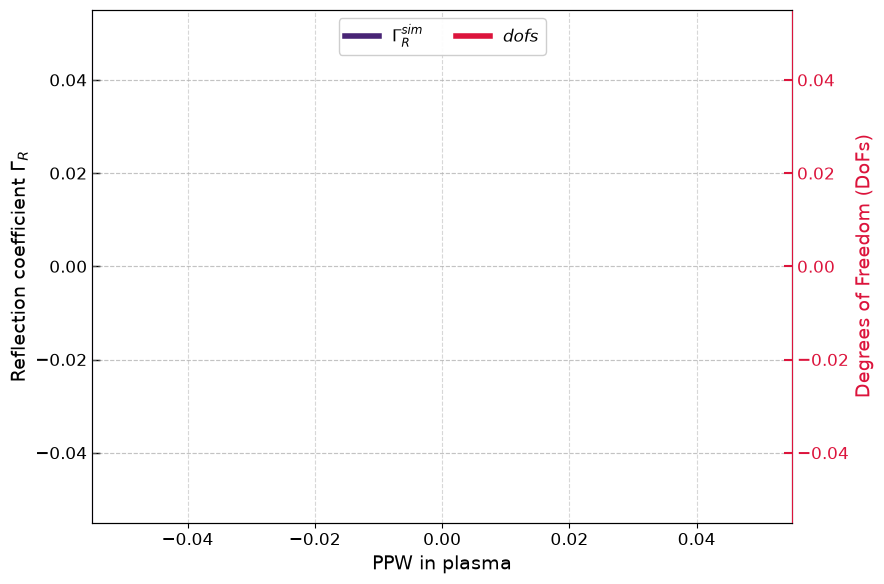

param_values: []
 ==== key: Sx_im ====
dofs: []
Gamma_R: []
Lx_pml: []
parameter_is_ppw: None
  -> Graphe sauvegardé : Analyse_Spectrale_Sweep_Sx_imag.svg


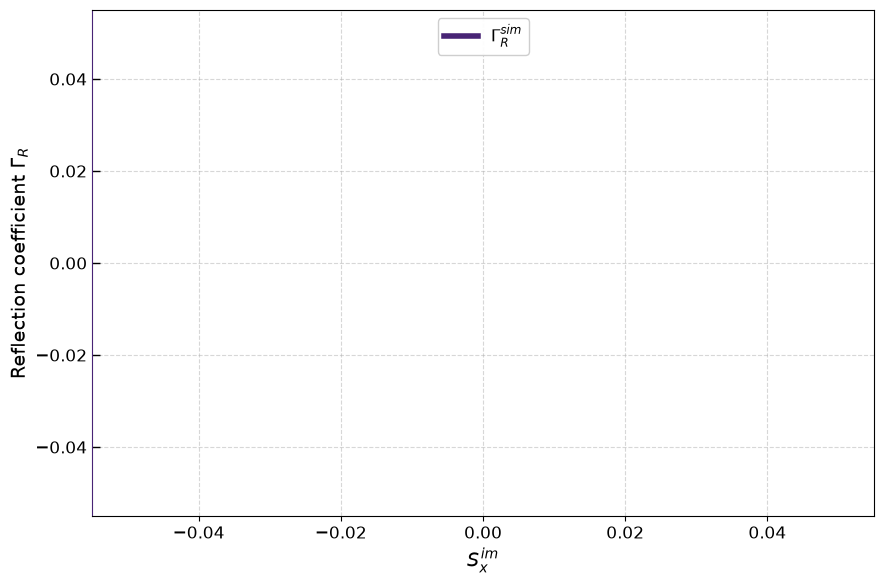

param_values: []
 ==== key: Sx_r ====
dofs: []
Gamma_R: []
Lx_pml: []
parameter_is_ppw: None
  -> Graphe sauvegardé : Analyse_Spectrale_Sweep_Sx_real.svg


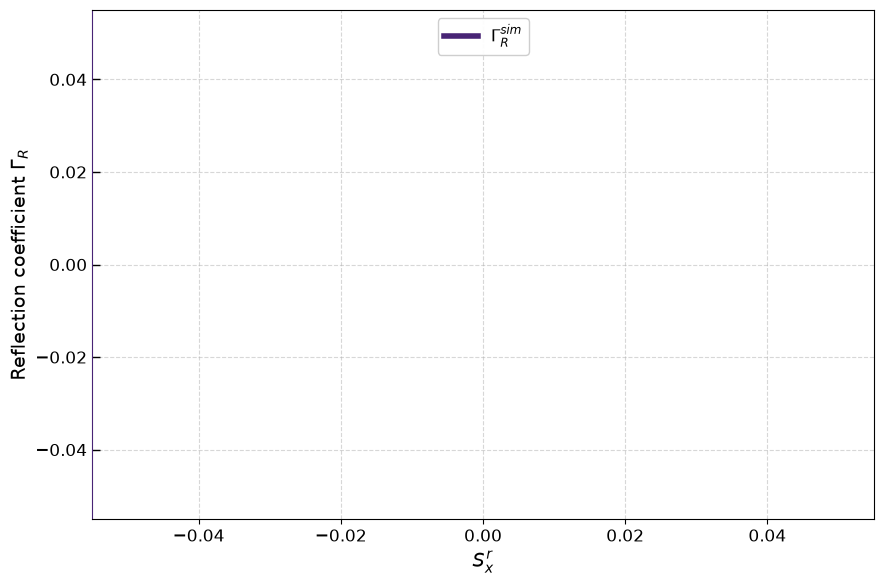

param_values: []
 ==== key: px ====
dofs: []
Gamma_R: []
Lx_pml: []
parameter_is_ppw: None
  -> Graphe sauvegardé : Analyse_Spectrale_Sweep_px.svg


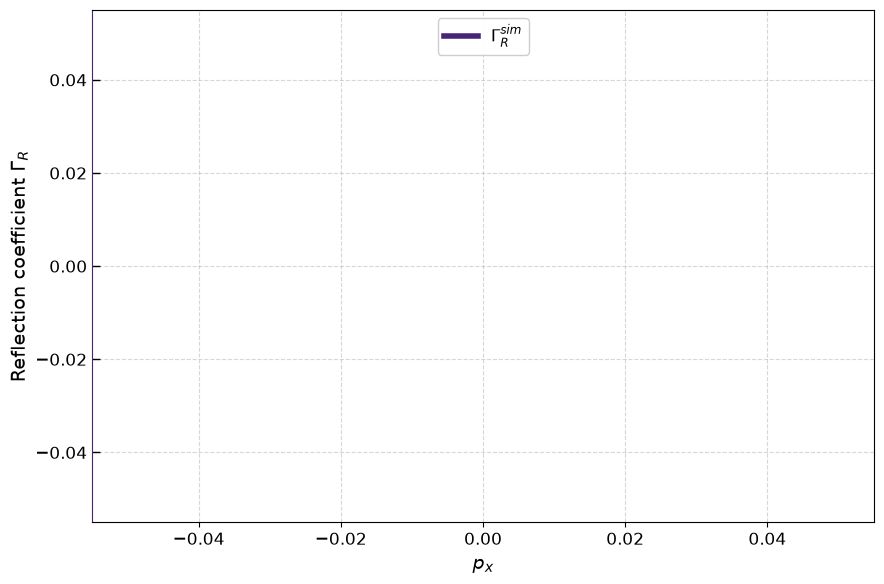

In [12]:
import sweep_param_functions as spf
# db_filepath
# Vide Radial 1D 40 pts: Simulation_Results/PML_1D_VACUUM_40pts.h5
# PLASMA Radial 1D n_para = 2, 5 avec 40pts: Simulation_Results/1D_PLASMA_40pts.h5
# PLASMA radial 1D n_para = 20, 50 avec 20pts: Simulation_Results/1D_PLASMA_n_para_20_et_50_20pts.h5
# PLASMA radial 1D n_para = 3 avec 20pts: Simulation_Results/1D_PLASMA_n_para=3_Lx_pml=2_to_4_5_20pts.h5
# PLASMA radial 1D n_para=2.5 to 3.5 20pts: 1D_PLASMA_n_para=2_5_to_3_5__Lx_pml=2_to4_5_20pts.h5
# Simulation_Results/1D_PLASMA_n_para=2_ppw_medium_pml_10_to_60.h5
# Simulation_Results/1D_PLASMA_n_para=2_ppw_medium_pml_1_18.h5
# Simulation_Results/1D_PLASMA_n_para=2_3_5_40pts.h5
# Simulation_Results/1D_PLASMA_n_para=2_ppw_6_to_20_40pts.h5

# Simulation_Results/PML_Radial_1D_Database_20260630_175333.h5 (A RE-TRAVAILLER)

# Simulation_Results/1D_PLASMA_gamma_R_vs_n_para_-10_-2__2_10.h5
# Simulation_Results/1D_PLASMA_gamma_R_vs_n_para_-2_-1_25_and_1_25_2


# Simulation_Results/1D_VACUUM_n_para=0_40pts.h5

spf.plot_sweeps_all_npara("Simulation_Results/1D_PLASMA_n_para=2_ppw_6_to_20_40pts.h5")

In [ ]:
# import sweep_param_functions as spf
# dataset_files = ["Simulation_Results/1D_VACUUM_n_para=0_40pts.h5", "Simulation_Results/1D_PLASMA_40pts.h5",
#                  "Simulation_Results/1D_PLASMA_n_para_20_et_50_20pts.h5"]

#     # 1. Check Mesh Stability
# spf.plot_aggregated_thermodynamics(dataset_files, target_params=['ppw_medium'])
    
#     # 2. Prove Global Independence across the Spectrum
# spf.plot_aggregated_thermodynamics(dataset_files, target_params=['n_para'])
    
#     # 3. Prove PML parameter decoupling
# spf.plot_aggregated_thermodynamics(dataset_files, target_params=['Sx_im', 'px', 'Lx_pml_ratio'])

--- Poynting Diagnostics: Processing 3 Datasets ---
  -> Graphe (Fractions) sauvegardé : Thermodynamic_Fractions_ppw_medium.png
  -> Graphe (Erreur) sauvegardé : 1D_power_conservation_ppw_medium.svg
--- Poynting Diagnostics: Processing 3 Datasets ---
--- Poynting Diagnostics: Processing 3 Datasets ---
  -> Graphe (Fractions) sauvegardé : Thermodynamic_Fractions_Lx_pml_ratio.png
  -> Graphe (Erreur) sauvegardé : 1D_power_conservation_Lx_pml_ratio.svg
  -> Graphe (Fractions) sauvegardé : Thermodynamic_Fractions_Sx_im.png
  -> Graphe (Erreur) sauvegardé : 1D_power_conservation_Sx_im.svg
  -> Graphe (Fractions) sauvegardé : Thermodynamic_Fractions_px.png
  -> Graphe (Erreur) sauvegardé : 1D_power_conservation_px.svg


--- Generating 1D Vacuum Validation Plots from: Simulation_Results/1D_VACCUM_n_para=0_40pts.h5 ---
  -> Graphe 1 sauvegardé : 1D_VACUUM_Gamma_R_sim_vs_Sx_r_n_Sx_im.svg


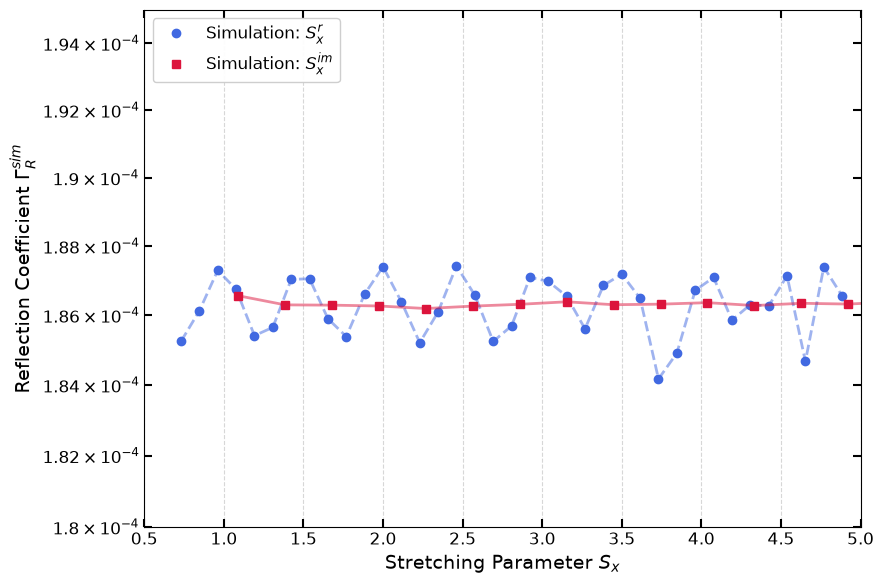

  -> Graphe 2 sauvegardé : 1D_VACUUM_Gamma_R_sim_vs_px.svg


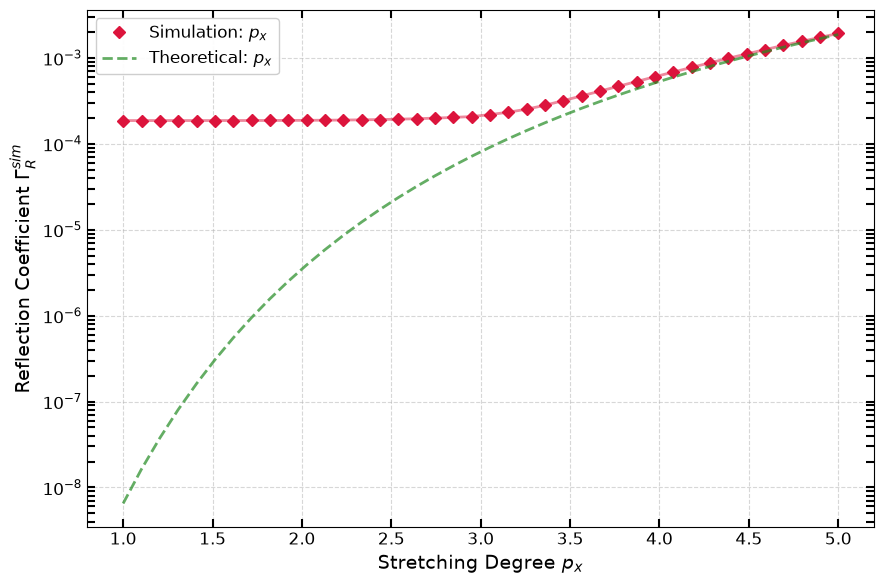

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'figure.figsize': (9, 6),
    'axes.grid': True,
    'grid.alpha': 0.5,
    'grid.linestyle': '--'
})

def extract_sweep_data(h5f, sweep_name):
    """
    Helper function to safely extract param_values, eta_sim, and eta_pred 
    from a specific sweep group in the HDF5 file.
    """
    if sweep_name not in h5f:
        print(f"[!] Warning: {sweep_name} not found in the dataset.")
        return None, None, None
        
    grp = h5f[sweep_name]
    param_values = grp['param_values'][:]
    
    # Dynamically find the n_para subgroup (in vacuum, this is usually n_para_0.0)
    n_para_keys = [k for k in grp.keys() if k.startswith('n_para_')]
    if not n_para_keys:
        return None, None, None
        
    subgrp = grp[n_para_keys[0]]
    eta_sim = subgrp['eta_sim'][:]
    eta_pred = subgrp['eta_pred'][:]
    
    return param_values, eta_sim, eta_pred

def plot_vacuum_pml_validation(h5_filepath):
    """
    Reads a 1D Vacuum HDF5 dataset and generates two specific comparison graphs:
    1. Gamma_R (Sim vs Pred) for Sx_r and Sx_im on the same axes.
    2. Gamma_R (Sim vs Pred) for px.
    """
    print(f"--- Generating 1D Vacuum Validation Plots from: {h5_filepath} ---")
    
    try:
        with h5py.File(h5_filepath, 'r') as h5f:
            
            # Extract data for Graph 1 (Sx_r and Sx_im)
            sx_r_vals, sim_r, pred_r = extract_sweep_data(h5f, 'Sweep_Sx_real')
            sx_i_vals, sim_i, pred_i = extract_sweep_data(h5f, 'Sweep_Sx_imag')
            
            # Extract data for Graph 2 (px)
            px_vals, sim_px, pred_px = extract_sweep_data(h5f, 'Sweep_px')
            
    except Exception as e:
        print(f"[!] Failed to read the HDF5 file: {e}")
        return

    # =========================================================================
    # GRAPH 1: S_x^r and S_x^{im} Comparison
    # =========================================================================
    if sx_r_vals is not None and sx_i_vals is not None:
        fig1, ax1 = plt.subplots()
        
        # Plot Sx_r (Real part) in Blue
        ax1.plot(sx_r_vals[2:-1], sim_r[2:-1], marker='o', linestyle='', color='royalblue', lw=2, label=r'Simulation: $S_x^r$')
        ax1.plot(sx_r_vals[2:-1], sim_r[2:-1], marker='', linestyle='--', color='royalblue', lw=2, alpha=0.5)
        # Plot Sx_im (Imaginary part) in Red
        ax1.plot(sx_i_vals[2:20], sim_i[2:20], marker='s', linestyle='', color='crimson', lw=2, label=r'Simulation: $S_x^{im}$')
        ax1.plot(sx_i_vals[2:20], sim_i[2:20], marker='', linestyle='-', color='crimson', lw=2, alpha=0.5)

        ax1.set_xlim(0.5, 5)
        ax1.set_ylim(1.8e-04, 1.95e-04)
        ax1.set_yscale('log')
        ax1.set_xlabel("Stretching Parameter $S_x$", fontsize=14)
        ax1.set_ylabel(r"Reflection Coefficient $\Gamma_R^{{sim}}$", fontsize=14)
        #ax1.set_title("Validation Théorique PML : Partie Réelle vs Imaginaire")
        
        # Move legend outside to prevent overlapping with the data curves
        ax1.legend(loc='upper left', framealpha=0.95)
        plt.tick_params(which="both", direction='in', length=6, width=1.5, right=True,
                                                   left=True, bottom=True, top=True)              
        plt.tight_layout()
        save_name1 = "1D_VACUUM_Gamma_R_sim_vs_Sx_r_n_Sx_im.svg"
        plt.savefig(save_name1, dpi=300, bbox_inches='tight')
        print(f"  -> Graphe 1 sauvegardé : {save_name1}")
        plt.show()

    # =========================================================================
    # GRAPH 2: Polynomial Degree (p_x)
    # =========================================================================
    if px_vals is not None:
        fig2, ax2 = plt.subplots()
        
        # Plot px in Green
        ax2.plot(px_vals, sim_px, marker='D', linestyle='', color='crimson', lw=2, label=r'Simulation: $p_x$')
        ax2.plot(px_vals, sim_px, marker='', linestyle='-', color='crimson', lw=2, alpha=0.5)

        ax2.plot(px_vals, pred_px, marker='', linestyle='--', color='forestgreen', lw=2, alpha=0.7, label=r'Theoretical: $p_x$')
        
        ax2.set_yscale('log')
        ax2.set_xlabel(r"Stretching Degree $p_x$", fontsize=14)
        ax2.set_ylabel(r"Reflection Coefficient $\Gamma_R^{{sim}}$",fontsize=14)
        #ax2.set_title("Validation Théorique PML : Influence du profil polynomial")
        
        ax2.legend(loc='best', framealpha=0.95)
        plt.tick_params(which="both", direction='in', length=6, width=1.5, right=True,
                                                   left=True, bottom=True, top=True)
        plt.tight_layout()
        save_name2 = "1D_VACUUM_Gamma_R_sim_vs_px.svg"
        plt.savefig(save_name2, dpi=300, bbox_inches='tight')
        print(f"  -> Graphe 2 sauvegardé : {save_name2}")
        plt.show()

# Execution example:
plot_vacuum_pml_validation("Simulation_Results/1D_VACCUM_n_para=0_40pts.h5")

In [ ]:
file_list = ["Simulation_Results/1D_PLASMA_n_para=2_ppw_medium_pml_10_to_60.h5", 
"Simulation_Results/1D_PLASMA_n_para=2_ppw_medium_pml_1_18.h5", "Simulation_Results/1D_PLASMA_n_para=2_ppw_6_to_20_40pts.h5"]

# file_list = ["Simulation_Results/1D_PLASMA_gamma_R_vs_n_para_-10_-2__2_10.h5", 
#              "Simulation_Results/1D_PLASMA_gamma_R_vs_n_para_-2_-1_25_and_1_25_2.h5"]
import sweep_param_functions as spf
spf.plot_concatenated_general_sweeps(file_list)

--- Universal Aggregation: Processing 1 Datasets ---
has_dofs for Sweep_Lpml_Ratio: True
  -> Graphe agrégé sauvegardé : Aggregated_Lx_pml_ratio.svg
has_dofs for Sweep_Resolution_PPW: True
  -> Graphe agrégé sauvegardé : Aggregated_ppw_pml.svg
has_dofs for Sweep_Resolution_PPW_Medium: True
  -> Graphe agrégé sauvegardé : Aggregated_ppw_medium.svg
has_dofs for Sweep_Sx_imag: True
  -> Graphe agrégé sauvegardé : Aggregated_Sx_im.svg
has_dofs for Sweep_Sx_real: True
  -> Graphe agrégé sauvegardé : Aggregated_Sx_r.svg
has_dofs for Sweep_px: True
  -> Graphe agrégé sauvegardé : Aggregated_px.svg


In [ ]:
import PLASMA_1D_Sobol_Surrogate as sob_sur
sob_sur.df_doe, problem_dict = sob_sur.generate_sobol_doe(N_base=2)
print("\nFirst 5 rows of the Physical DoE:")
print(sob_sur.df_doe.head())

--- Generating Sobol DoE for PML Surrogate Model ---
[+] Sobol sequence generated. Total unique simulations required: 28
[+] DoE saved successfully to 'DoE_Sobol_PML_6D.csv'

First 5 rows of the Physical DoE:
       Sx_r     Sx_im        px  Lx_pml_ratio  log10_ne_edge  ne_edge_linear  \
0  4.769082  3.554908  3.237787      1.802020      18.444931    2.785679e+18   
1  2.376619  3.554908  3.237787      1.802020      18.444931    2.785679e+18   
2  4.769082  1.349084  3.237787      1.802020      18.444931    2.785679e+18   
3  4.769082  3.554908  1.600692      1.802020      18.444931    2.785679e+18   
4  4.769082  3.554908  3.237787      0.323349      18.444931    2.785679e+18   

   log10_n_para  n_para_linear  Gamma_R  DoFs  Conservation_Error  
0      0.360319       2.292548      NaN   NaN                 NaN  
1      0.360319       2.292548      NaN   NaN                 NaN  
2      0.360319       2.292548      NaN   NaN                 NaN  
3      0.360319       2.292548      Na

In [ ]:
import PLASMA_1D_Sobol_Surrogate as sob_sur
sob_sur.run_phase2_batch_multiprocess("DoE_Sobol_PML_6D.csv", max_workers=4)

--- Starting Phase 2: Multiprocessed FEM Batch ---
[*] Allocating strictly 2 CPU cores to protect VM resources.
[*] Found 28 remaining simulations to execute.
n_e = 2.79e+18 m^-3
n_acc(ne=2.79e+18 m^-3) = 1.15
In LHCoupling class: n_para: 2.3, n_perp_p: 7.99e+00+0.00e+00j, n_perp_m: 0.00e+00+2.05e+00j
n_e = 2.79e+18 m^-3
n_acc(ne=2.79e+18 m^-3) = 1.15
n_e = 2.79e+18 m^-3
n_acc(ne=2.79e+18 m^-3) = 1.15
In LHCoupling class: n_para: 2.3, n_perp_p: 7.99e+00+0.00e+00j, n_perp_m: 0.00e+00+2.05e+00j
geom_mode: 1D
box_medium: PLASMA
==== 
Lx_plasma: 5.00e-02m,   Lx_pml: 1.83e-02m,    Lx_tot: 6.83e-02m
Lx_wg = 0.00e+00m
Lz_antenna: 0.00e+00m, Lz_wall: 0.00e+00m
Lz_plasma: 1.06e-01m, Lz_pml: 0.00e+00m, Lz_tot: 1.06e-01m
==== 
n_∥: 2.3,   λ_∥: 3.53e-02m 
n_⟂⁺:7.99+0.00j, λ_⟂⁺: 1.01e-02m 
n_⟂-:0.00+2.05j, λ_⟂⁻: 3.96e-02m
==== 
n_index_meshing: 7.99 
λ_meshing: 1.01e-02m 
maxh_plasma: 1.27e-03m
[DOMAIN 1D DEFINED]
n_e = 2.79e+18 m^-3
n_acc(ne=2.79e+18 m^-3) = 1.15
In LHCoupling class: n_para: 2.3, 

--- Phase 3: Training Gaussian Process Surrogate Models ---
[*] Loaded 28 simulations. Dropped 0 failed runs.

[*] Generating Learning Curve for: Gamma_R Surrogate


/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/.venv/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/.venv/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/.venv/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound 

  -> Saved diagnostic plot: Learning_Curve_Gamma_R_Surrogate.png


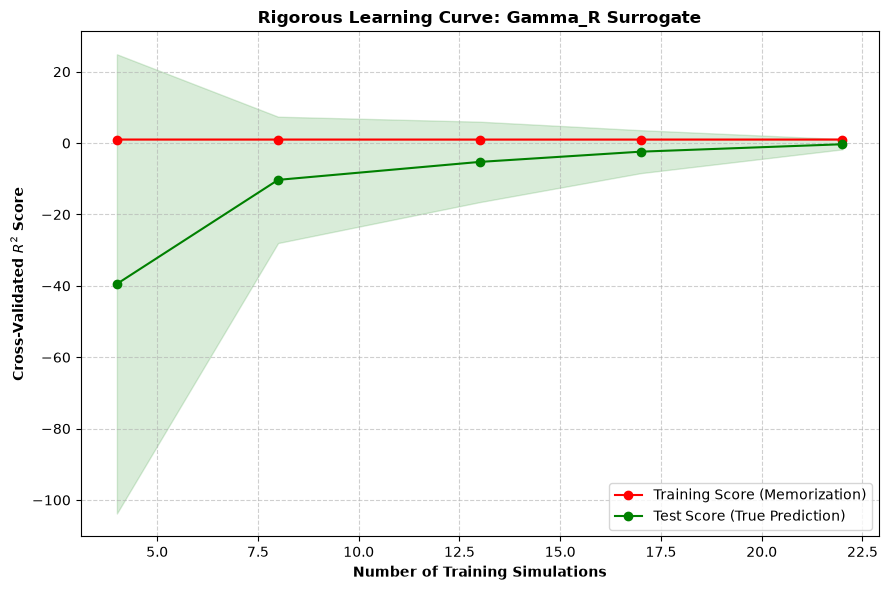


[*] Generating Learning Curve for: DoFs Surrogate


/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/.venv/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/.venv/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/.venv/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the

  -> Saved diagnostic plot: Learning_Curve_DoFs_Surrogate.png


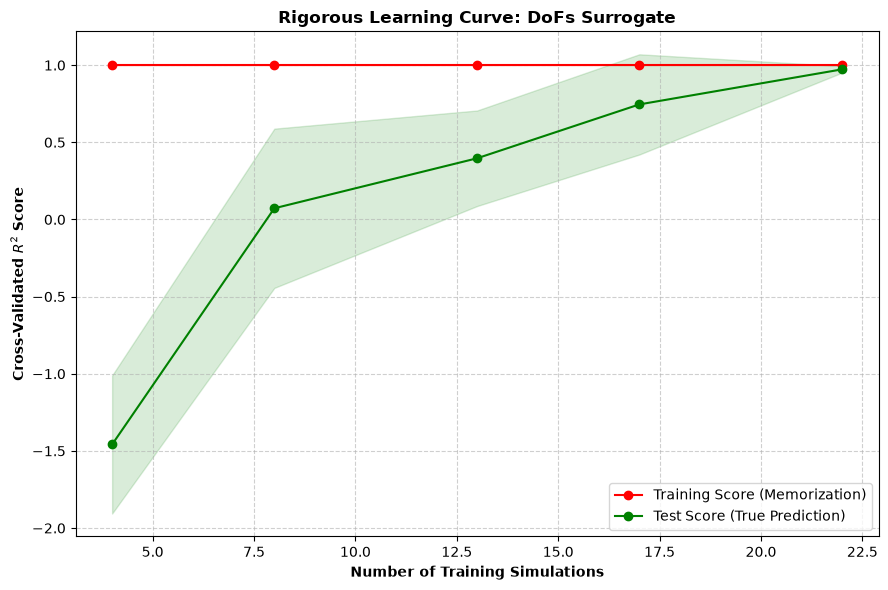


[*] Training Gamma_R Surrogate (This may take a minute on large datasets)...


/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/.venv/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/.venv/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


[*] Training DoFs Surrogate...

--- Model Validation Scores (R^2) ---
Gamma_R Model R^2 : 0.5544 (1.0 is perfect)
DoFs Model R^2    : 0.9930 (1.0 is perfect)
Optimized Gamma Kernel: 1.34**2 * Matern(length_scale=[1e+05, 15.7, 20.7, 3.01, 10.4, 4.17], nu=2.5) + WhiteKernel(noise_level=0.00281)

[+] Models and Scaler successfully saved to disk.
[+] Validation plot saved as 'Surrogate_Validation.png'


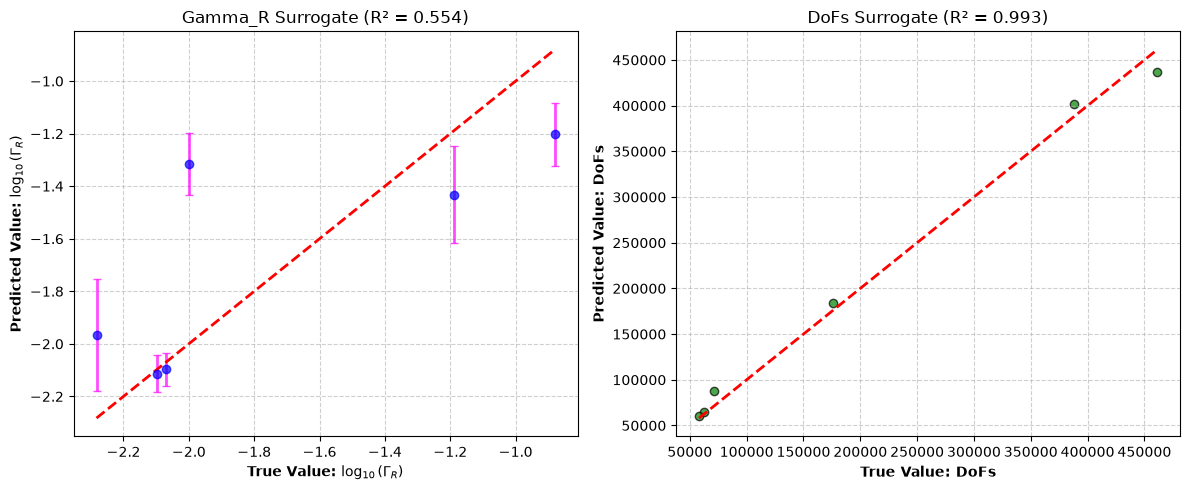

In [ ]:
import PLASMA_1D_Sobol_Surrogate as sob_sur
sob_sur.train_surrogate_models("DoE_Sobol_PML_6D.csv")

--- Phase 4: Global Sensitivity Analysis via Surrogate ---
[*] Generating 10000 base samples for Monte Carlo integration...


/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/.venv/lib/python3.11/site-packages/SALib/sample/sobol.py:136: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  base_sequence = qrng.random(N)


[*] Total surrogate evaluations required: 140000
[*] Evaluating surrogate model...
[*] Computing Sobol Variance Indices...
[+] Sensitivity bar chart saved to 'Sobol_Sensitivity_Indices.png'


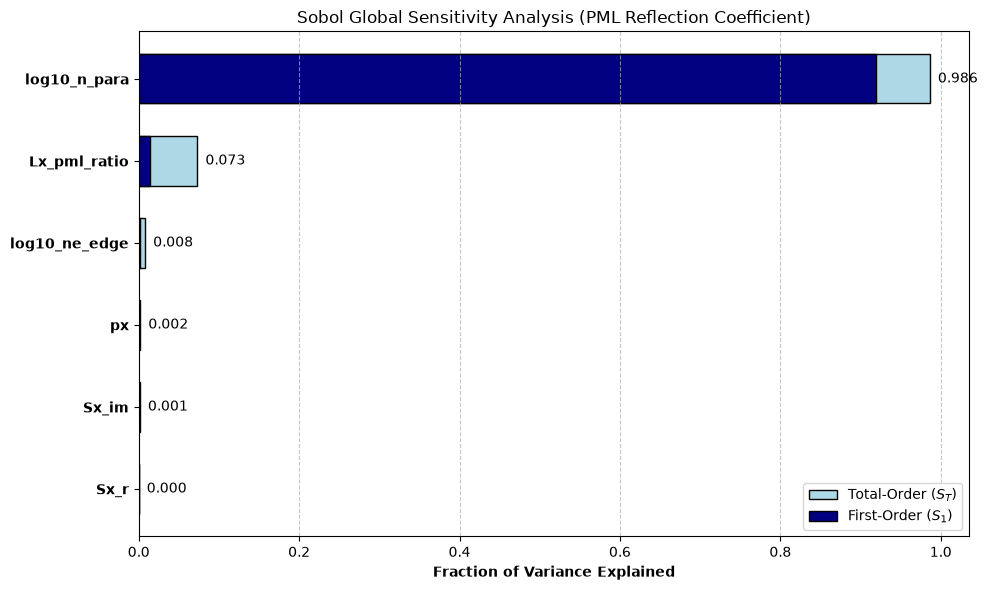


--- Physical Conclusions ---
log10_n_para: Total Impact = 98.6% | Interaction = 6.8%
Lx_pml_ratio: Total Impact = 7.3% | Interaction = 5.9%
log10_ne_edge: Total Impact = 0.8% | Interaction = 0.7%
px: Total Impact = 0.2% | Interaction = 0.2%
Sx_im: Total Impact = 0.1% | Interaction = 0.1%
Sx_r: Total Impact = 0.0% | Interaction = -0.0%


In [ ]:
import PLASMA_1D_Sobol_Surrogate as sob_sur
sob_sur.compute_sobol_indices()

In [ ]:
import PLASMA_1D_Sobol_Surrogate as sob_sur
sob_sur.robust_pml_optimization(max_allowed_dofs=15000)

--- Phase 5: Robust Weighted Optimization ---
[*] Launching Differential Evolution Optimizer...
[*] Constraint: Max DoFs = 15000
[*] Weighting: Exponential decay favoring low n_parallel
differential_evolution step 1: f(x)= 183697406.30616406
differential_evolution step 2: f(x)= 183697406.30616406
differential_evolution step 3: f(x)= 175005730.13541785
differential_evolution step 4: f(x)= 175005730.13541785
differential_evolution step 5: f(x)= 162195256.09970805
differential_evolution step 6: f(x)= 162195256.09970805
differential_evolution step 7: f(x)= 157533492.82425916
differential_evolution step 8: f(x)= 157213958.58246583
differential_evolution step 9: f(x)= 157122445.65386775
differential_evolution step 10: f(x)= 153283031.58891198
differential_evolution step 11: f(x)= 153283031.58891198
differential_evolution step 12: f(x)= 152968392.96920878
differential_evolution step 13: f(x)= 152968392.96920878
differential_evolution step 14: f(x)= 151866500.25260866
differential_evolution st

In [ ]:
import numpy as np
import copy
import matplotlib.pyplot as plt
import joblib

# Import your actual FEM solver
from config_dict import cfg as base_cfg 
from solver_2DHcurl_1DH1 import LHCouplingSolver_2DHcurl_1DH1

def final_validation_sweep(opt_params, ne_test=3e18):
    """
    Validates the Phase 5 optimal parameters by running the real NGSolve FEM 
    across the entire n_parallel spectrum and comparing it to the Surrogate model.
    """
    print("--- Phase 6: Final Ground-Truth Validation ---")
    
    # 1. Extract the optimal parameters from Phase 5
    Sx_r_opt, Sx_im_opt, px_opt, Lx_ratio_opt = opt_params
    print(f"[*] Testing Universal PML: Sx_r={Sx_r_opt:.2f}, Sx_im={Sx_im_opt:.2f}, px={px_opt:.2f}, L_ratio={Lx_ratio_opt:.2f}")
    
    # 2. Load the trained surrogate to compare predictions
    try:
        gpr_gamma = joblib.load('surrogate_gamma.pkl')
        scaler = joblib.load('feature_scaler.pkl')
    except Exception as e:
        print("[!] Warning: Surrogate models not found for comparison.")
        gpr_gamma = None
        
    # 3. Define the validation spectrum
    n_para_sweep = np.linspace(2.0, 80.0, 20)
    
    real_gamma_list = []
    pred_gamma_list = []
    
    for n_para in n_para_sweep:
        print(f"  -> Solving FEM for n_para = {n_para:.1f} ...")
        
        # --- Real FEM Execution ---
        scan_cfg = copy.deepcopy(base_cfg)
        scan_cfg['PML']['Sx_r'] = Sx_r_opt
        scan_cfg['PML']['Sx_im'] = Sx_im_opt
        scan_cfg['PML']['px'] = px_opt
        scan_cfg['PLASMA']['ne_constant'] = ne_test
        scan_cfg['WAVE']['n_para'] = n_para
        
        # Geometry scaling
        temp_solver = LHCouplingSolver_2DHcurl_1DH1(scan_cfg, geom_mode="1D", box_medium="PLASMA", antenna_grill=None)
        _, n_perp_p, _ = temp_solver.compute_physics_parameters()
        lambda_perp = scan_cfg['WAVE']['lambda0'] / np.abs(n_perp_p.real)
        scan_cfg['DOMAIN']['Lx_pml'] = Lx_ratio_opt * lambda_perp
        scan_cfg['DOMAIN']['Lx_tot'] = scan_cfg['DOMAIN']['Lx_plasma'] + scan_cfg['DOMAIN']['Lx_pml']
        del temp_solver
        
        # Solve
        try:
            solver = LHCouplingSolver_2DHcurl_1DH1(scan_cfg, geom_mode="1D", box_medium="PLASMA", antenna_grill=None)
            mesh = solver.build_mesh_with_PMLs()
            solver.build_physics_Stix_B_field()
            _, Gamma_R, _, _ = solver.solve_helmholtz_2DHcurl_1DH1_with_pml(mesh, "1D", "PLASMA")
            real_gamma_list.append(Gamma_R)
        except Exception as e:
            print(f"     [!] FEM Failed: {e}")
            real_gamma_list.append(np.nan)
            
        # --- Surrogate Prediction ---
        if gpr_gamma is not None:
            # Build the 6D feature vector exactly as in Phase 3
            X_test = np.array([[Sx_r_opt, Sx_im_opt, px_opt, Lx_ratio_opt, np.log10(ne_test), np.log10(n_para)]])
            X_scaled = scaler.transform(X_test)
            pred_log_gamma = gpr_gamma.predict(X_scaled)[0]
            pred_gamma_list.append(10 ** pred_log_gamma)
            
    # 4. Plot the Validation Results
    plt.figure(figsize=(9, 6))
    
    plt.plot(n_para_sweep, real_gamma_list, marker='o', linestyle='-', color='black', lw=2, label='True FEM Physics')
    
    if gpr_gamma is not None:
        plt.plot(n_para_sweep, pred_gamma_list, marker='x', linestyle='--', color='red', lw=2, label='Surrogate Prediction')
        
    plt.yscale('log')
    plt.xlabel(r"Parallel Refractive Index ($n_\parallel$)", fontweight='bold')
    plt.ylabel(r"Reflection Coefficient ($\Gamma_R$)", fontweight='bold')
    plt.title(f"Universal PML Performance Validation ($n_e = {ne_test:.1e}$)")
    plt.grid(True, which="both", ls="--", alpha=0.6)
    plt.legend()
    
    plt.tight_layout()
    plt.savefig("Phase6_Final_Validation.png", dpi=300)
    plt.show()

if __name__ == "__main__":
    # Replace this array with the output from Phase 5 once your 3500-run batch finishes
    # [Sx_r, Sx_im, px, Lx_ratio]
    dummy_optimal_params = [1.5, 3.0, 2.5, 1.0] 
    final_validation_sweep(dummy_optimal_params, ne_test=3e18)v